# Лабораторная работа №1  
## Разведочный анализ данных  

**Выполнил:** Денефельд Валерия Максимовна  
**Группа:** ИБМ3-64Б  
**Дисциплина:** Технологии машинного обучения  
**Дата:** 01.03.2026

Описание задания

Требуется выполнить разведочный анализ данных (EDA) на небольшом датасете без пропусков, построить базовые визуализации распределений и взаимосвязей признаков, а также исследовать корреляцию между признаками.
В качестве набора данных используется датасет Iris из библиотеки Scikit-learn.

In [1]:
# Импорт библиотек
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print("Импорты выполнены успешно")

Импорты выполнены успешно


In [4]:
df.shape

(150, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

## 3. Визуальное исследование датасета

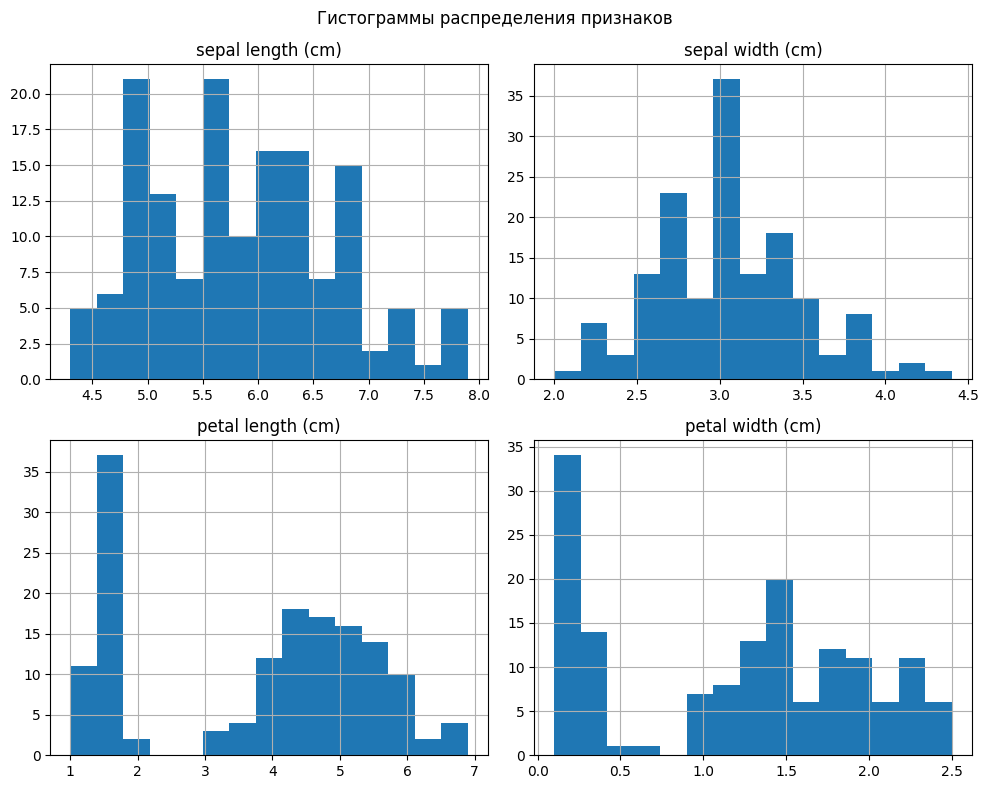

In [7]:
# Гистограммы распределений признаков
df[iris.feature_names].hist(bins=15, figsize=(10, 8))
plt.suptitle("Гистограммы распределения признаков")
plt.tight_layout()
plt.show()

Вывод: распределения признаков не являются полностью симметричными. 
Признаки длины и ширины лепестка демонстрируют более выраженную структуру, 
что может свидетельствовать о лучшей разделимости видов по этим признакам.

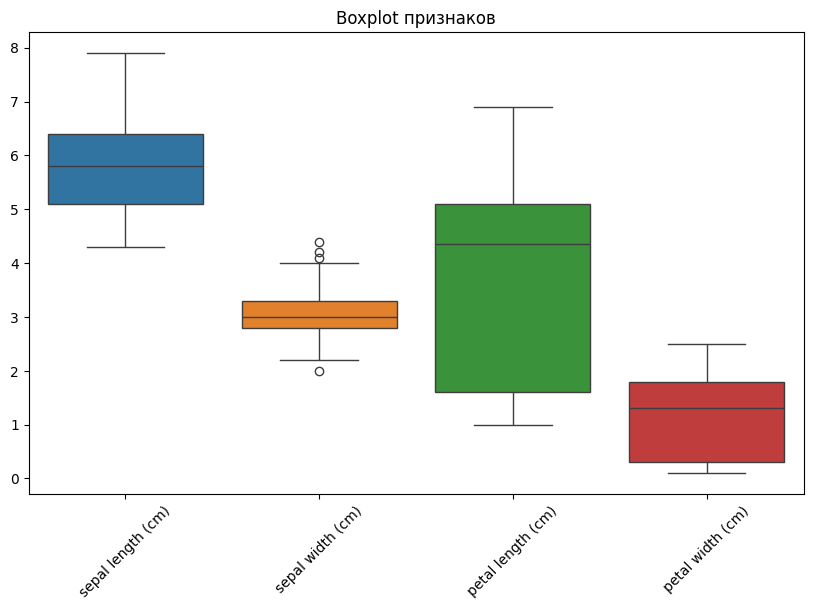

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[iris.feature_names])
plt.xticks(rotation=45)
plt.title("Boxplot признаков")
plt.show()

Вывод: признаки лепестков имеют меньшие абсолютные значения, 
но демонстрируют значительный межквартильный размах. 
Явных экстремальных выбросов не наблюдается.

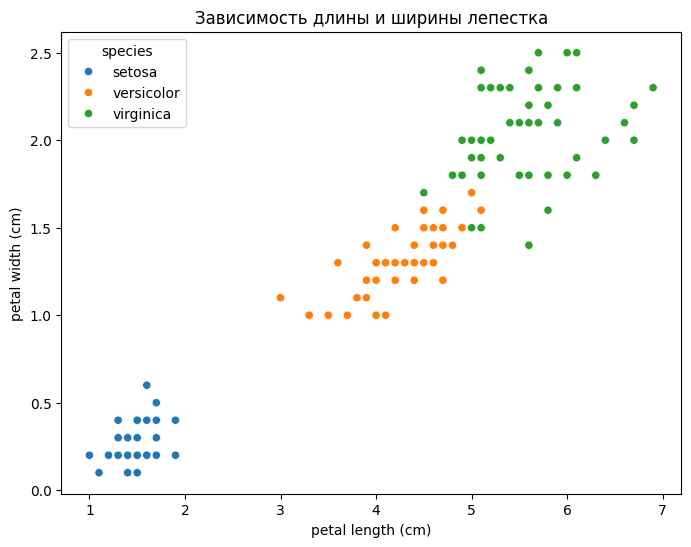

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)
plt.title("Зависимость длины и ширины лепестка")
plt.show()

Вывод: по длине и ширине лепестка виды ирисов хорошо разделяются. 
Это подтверждает информативность данных признаков для задач классификации.

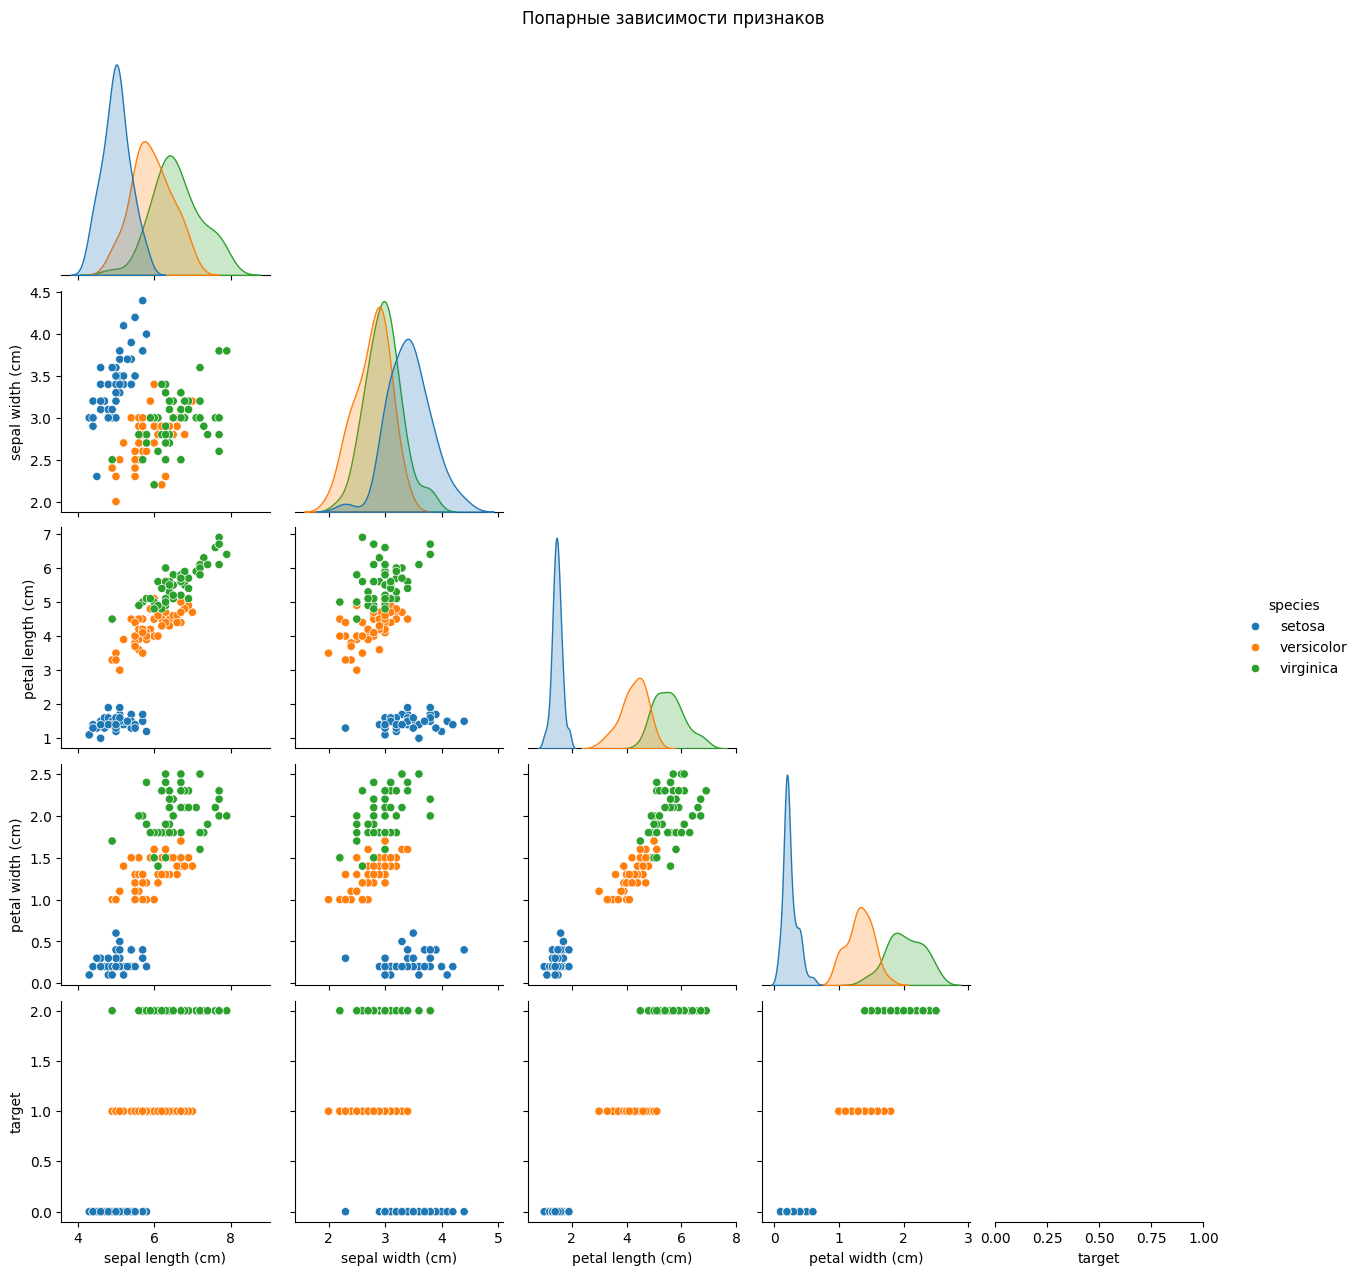

In [10]:
sns.pairplot(df, hue="species", corner=True)
plt.suptitle("Попарные зависимости признаков", y=1.02)
plt.show()

Вывод: признаки длины и ширины лепестка обеспечивают наилучшую визуальную разделимость классов. Признаки чашелистиков демонстрируют частичное перекрытие классов versicolor и virginica.

## 4. Анализ корреляции признаков

In [11]:
corr = df[iris.feature_names].corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


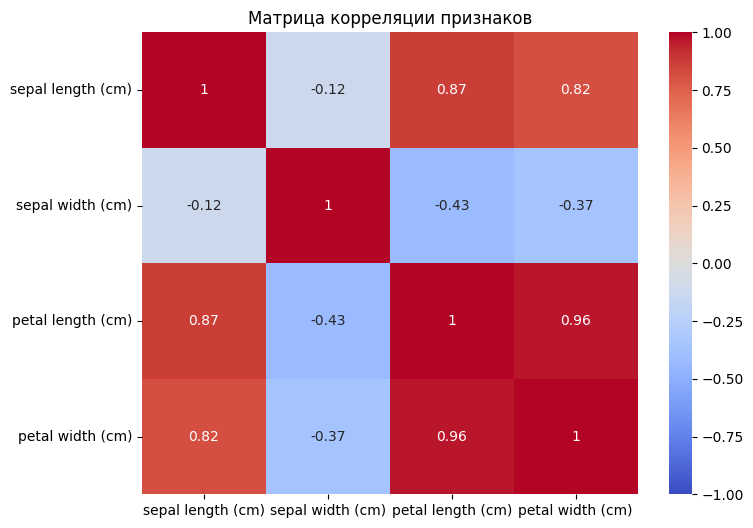

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков")
plt.show()

Вывод: 
1. Самая сильная корреляция — между petal length и petal width (≈ 0.96).
Это почти линейная зависимость.
2. sepal length также достаточно сильно коррелирует с признаками лепестка (0.82–0.87).
3. sepal width демонстрирует слабую или умеренную отрицательную корреляцию с остальными признаками.
4. Признаки лепестка являются наиболее информативными для разделения классов, что подтверждено как scatter-графиком, так и корреляционным анализом.

Наиболее сильная корреляция наблюдается между длиной и шириной лепестка. Это свидетельствует о возможной избыточности одного из признаков при построении модели. Признаки чашелистиков менее коррелированы с другими и могут вносить дополнительную информацию.

## Итоговый вывод

В ходе выполнения лабораторной работы был проведён разведочный анализ датасета Iris. Датасет содержит 150 наблюдений и 4 числовых признака, пропуски отсутствуют.

Анализ распределений показал различие диапазонов значений признаков. Визуализация зависимостей продемонстрировала чёткую разделимость классов по признакам длины и ширины лепестка.

Корреляционный анализ выявил сильную положительную связь между длиной и шириной лепестка (коэффициент ≈ 0.96), что может указывать на частичную избыточность признаков. Признаки чашелистика менее коррелированы с остальными и могут вносить дополнительную информацию в модель.

Таким образом, датасет подходит для решения задач классификации, а наиболее информативными признаками являются характеристики лепестка.